# ============================================================
# EPA LICENSEE WASTE DATA (2021-2024) 
# ============================================================

1. Descrição do Dataset
O dataset utilizado corresponde aos dados de resíduos de instalações licenciadas pela EPA (Environmental Protection Agency), abrangendo o período de 2021 a 2024.

# Primeiro: realidade importante sobre esse dataset da EPA

O dataset (EPA Licensee Waste Data) usa dados:
  Dados administrativos (reportados por empresas)
  Em formato tabular (Excel)
  Com variáveis como:
    quantidade de resíduos
    tipo de tratamento
    origem/destino
       .
       .
       .

 2. Alguns arquivos cientificos usaram dados do EPA ou derivados:
     - Environmental Protection Agency Ireland – Research 438 (Waste Crime + ML)
     - Environmental Protection Agency Ireland – Circular Economy + AI (Report 492)
     - Waste Flow Prediction (EU datasets)
 3. Dentre alguns problemas abordados estao:
     - Detectar waste crime (descarte ilegal)
     - Inspeção manual é limitada
     - Otimizar gestão de resíduos e políticas públicas
     - Impacto ambiental e econômico dos resíduos
# ============================================================
# Problema Sugerido
# ============================================================
    
    Prever:
        Quantidade de resíduos por tipo
        Fluxo entre instalações
        Risco de exportação ilegal

        

In [70]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import glob
import os
import re
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# ============================================================
# 2. DEFINE FOLDER PATH
# ============================================================

folder_path = r"C:\Users\55929\Desktop\CCT_Colege\dataset"

# Find all Excel files in the folder
files = glob.glob(os.path.join(folder_path, "*.xlsx"))

print("Files found:")
for f in files:
    print(f)


Files found:
C:\Users\55929\Desktop\CCT_Colege\dataset\EPA-Licensee-Waste-Data-2021.xlsx
C:\Users\55929\Desktop\CCT_Colege\dataset\EPA-Licensee-Waste-Data-2022.xlsx
C:\Users\55929\Desktop\CCT_Colege\dataset\EPA-Licensee-Waste-Data-2023.xlsx
C:\Users\55929\Desktop\CCT_Colege\dataset\EPA-Licensee-Waste-Data-2024.xlsx


# ============================================================
# 1. LOAD ONLY FILES FROM 2021 TO 2024
# ============================================================

Nas analises foram considrados os dados relacionados do anos de 2021 a 2024, com isso podemos garantir alguns aspectos fundamentais nas analises tais como:

 1. Mais robustez estatística
     - Mais dados → menor erro
     - médias mais confiáveis
 2.  Permite análise de tendência
        Exemplo:
          - Média de resíduos por ano
          - Taxa de exportação ao longo do tempo
 3. Melhor uso das distribuições como:
     - Binomial:
       .: 1 ano → uma única proporção
       .: 4 anos → você compara proporções entre anos

     - Poisson
       .:1 ano → contagem simples
       .:4 anos → contagem por facility-year

 * Muito mais correto estatisticamente

   - Normal
        .:1 ano → pode estar enviesado
        .:4 anos → mais próximo da realidade
 * Melhor aplicação do Central Limit Theorem
 4. Detecta padrões reais possibilita encontrar:
     - crescimento
     - estabilidade
     - sazonalidade
     - mudanças estruturais

In [71]:

df_list = []

for file in files:
    filename = os.path.basename(file)

    # Extract year from file name
    match = re.search(r'20(21|22|23|24)', filename)
    if match:
        year = int(match.group())
        temp_df = pd.read_excel(file)
        temp_df["year"] = year
        df_list.append(temp_df)

if len(df_list) == 0:
    raise ValueError("No Excel files from 2021 to 2024 were found.")

# Concatenate all files
df = pd.concat(df_list, ignore_index=True)


C:\Users\55929\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Data Validation extension is not supported and will be removed
  for idx, row in parser.parse():
C:\Users\55929\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Data Validation extension is not supported and will be removed
  for idx, row in parser.parse():
C:\Users\55929\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Data Validation extension is not supported and will be removed
  for idx, row in parser.parse():


In [72]:
print("\nCombined dataset shape:")
print(df.shape)


Combined dataset shape:
(31028, 16)


In [73]:
print("\nFirst 5 rows:")
df.head()


First 5 rows:


,Reporting Year,Licence Profile,Waste Source,Waste Action,List of Waste Code,Low Code Description,Respondent Waste Description,Accepted Waste Quantity,Accepted waste quantity from abroad,Accepted Waste Quantity from Ireland,On Site Waste Treatment Type,Waste Quantity Tonnes per Year,Next Destination Waste Treatment Type,Final Destination Abroad,Final Destination Waste Treatment Type,year
0,2021,Ashgrove Recycling - W0147,Waste Accepted,Waste Accepted,15 01 01,paper and cardboard packaging,Cardboard,40.58,0.0,40.58,R13 - Storage of waste pending any of the oper...,NaN,NaN,NaN,NaN,2021
1,2021,Ashgrove Recycling - W0147,Accepted,Transferred,15 01 01,paper and cardboard packaging,Cardboard,NaN,NaN,NaN,NaN,97.88,R13 - Storage of waste pending any of the oper...,NaN,NaN,2021
2,2021,Ashgrove Recycling - W0147,Waste Accepted,Waste Accepted,15 01 02,plastic packaging,plastic packaging,0.06,0.0,0.06,R13 - Storage of waste pending any of the oper...,NaN,NaN,NaN,NaN,2021
3,2021,Ashgrove Recycling - W0147,Accepted,Transferred,15 01 02,plastic packaging,Plastic Packaging,NaN,NaN,NaN,NaN,7.64,R13 - Storage of waste pending any of the oper...,NaN,NaN,2021
4,2021,Ashgrove Recycling - W0147,Waste Accepted,Waste Accepted,15 01 03,wooden packaging,wooden packaging,0.26,0.0,0.26,R13 - Storage of waste pending any of the oper...,NaN,NaN,NaN,NaN,2021


# ============================================================
# 2. STANDARDIZE COLUMN NAMES
# ============================================================

In [78]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("/", "_", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

print("\nStandardized columns:")
df.columns.tolist()


Standardized columns:


['reporting_year',
 'licence_profile',
 'waste_source',
 'waste_action',
 'list_of_waste_code',
 'low_code_description',
 'respondent_waste_description',
 'accepted_waste_quantity',
 'accepted_waste_quantity_from_abroad',
 'accepted_waste_quantity_from_ireland',
 'on_site_waste_treatment_type',
 'waste_quantity_tonnes_per_year',
 'next_destination_waste_treatment_type',
 'final_destination_abroad',
 'final_destination_waste_treatment_type',
 'year']

# 3. REMOVE COLUMNS WITH TOO MANY MISSING VALUES


In [79]:
missing_ratio = df.isnull().mean()
cols_to_drop = missing_ratio[missing_ratio > 0.70].index.tolist()

print("\nColumns dropped due to more than 70% missing values:")
print(cols_to_drop)

df = df.drop(columns=cols_to_drop)

print("\nDataset shape after dropping sparse columns:")
print(df.shape)


Columns dropped due to more than 70% missing values:
['next_destination_waste_treatment_type']

Dataset shape after dropping sparse columns:
(31028, 15)


# 4. CONVERT DATA TYPES

In [80]:
candidate_numeric_cols = [
    "accepted_waste_quantity",
    "accepted_waste_quantity_from_abroad",
    "accepted_waste_quantity_from_ireland",
    "waste_quantity_tonnes_per_year",
    "reporting_year",
    "year"
]

numeric_cols = [col for col in candidate_numeric_cols if col in df.columns]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

yes_no_cols = [
    "final_destination_also_next_destination",
    "next_destination_abroad",
    "final_destination_abroad"
]

for col in yes_no_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()

# 5. BASIC CLEANING

In [81]:
# Keep only valid rows for main target variable
if "accepted_waste_quantity" in df.columns:
    df = df[df["accepted_waste_quantity"].notna()]
    df = df[df["accepted_waste_quantity"] >= 0]

print("\nDataset shape after cleaning main quantity:")
print(df.shape)

print("\nMissing values after cleaning:")
print(df.isnull().sum())


Dataset shape after cleaning main quantity:
(12939, 15)

Missing values after cleaning:
reporting_year                                0
licence_profile                               0
waste_source                                  0
waste_action                                  0
list_of_waste_code                            0
low_code_description                          0
respondent_waste_description                142
accepted_waste_quantity                       0
accepted_waste_quantity_from_abroad           0
accepted_waste_quantity_from_ireland          0
on_site_waste_treatment_type                  0
waste_quantity_tonnes_per_year            12939
final_destination_abroad                      0
final_destination_waste_treatment_type    12939
year                                          0
dtype: int64


# ============================================================
# 6. Analise Heatmap of Correlation Matrix
# ============================================================

Colunas numéricas usadas na correlação:
Index(['reporting_year', 'accepted_waste_quantity', 'accepted_waste_quantity_from_abroad', 'accepted_waste_quantity_from_ireland', 'waste_quantity_tonnes_per_year', 'year'], dtype='object')


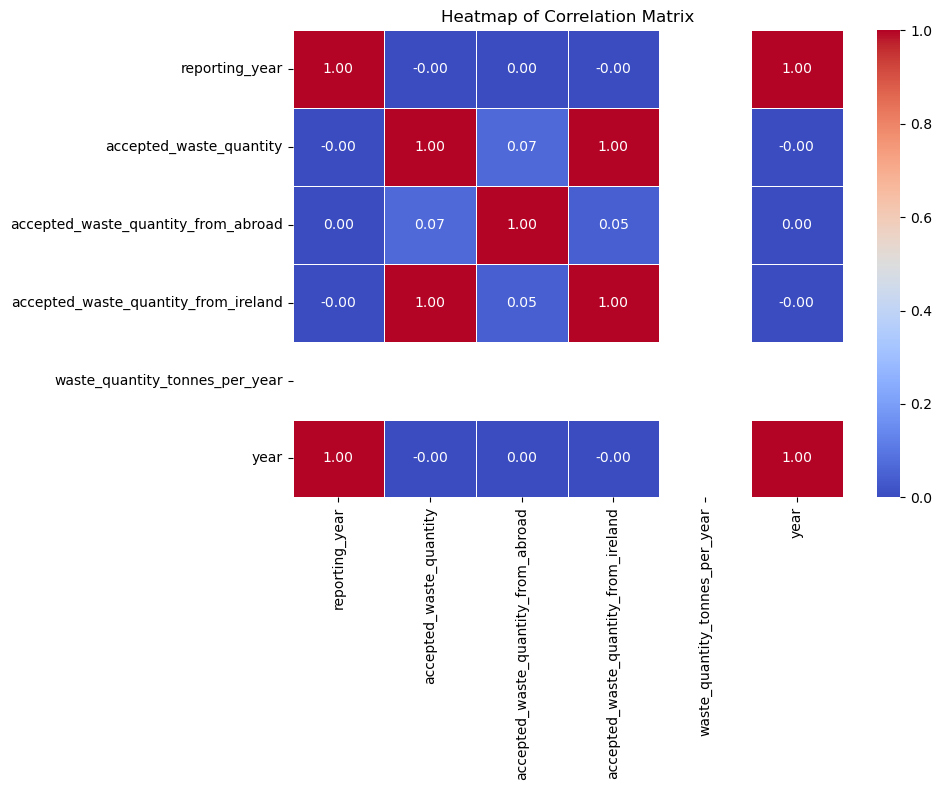

In [82]:
# ============================================================
# 1. Selecionar apenas colunas numéricas
# ============================================================

numeric_df = df.select_dtypes(include=['int64', 'float64'])

print("Colunas numéricas usadas na correlação:")
print(numeric_df.columns)

# ============================================================
# 2. Calcular matriz de correlação
# ============================================================

correlation_matrix = numeric_df.corr()

# ============================================================
# 3. Plotar Heatmap
# ============================================================

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,          # mostra valores
    fmt=".2f",           # 2 casas decimais
    cmap="coolwarm",     # cores
    linewidths=0.5
)

plt.title("Heatmap of Correlation Matrix")
plt.tight_layout()
plt.show()

# Apos a visualizacao da tabela do Heatmap foi possivel observar uma quantidade alta de valores ausentes
1. A inspeção visual dos dados revela uma forte concentração de valores de baixa magnitude, com repetição frequente de pequenos valores e presença limitada de valores mais elevados. Esse padrão confirma a assimetria previamente identificada na análise estatística descritiva, caracterizando uma distribuição com cauda longa à direita.

2. Além disso, a presença de intervalos discretos sugere que parte dos dados pode ter sido agregada ou arredondada, o que pode impactar a precisão de modelos estatísticos tradicionais. Essa característica reforça a necessidade de utilizar técnicas robustas de machine learning capazes de lidar com dados heterogêneos e não lineares.

# VERSÃO MELHOR (remover colunas problemáticas)

 - Como você tem colunas com muitos NaN (ex: waste_quantity_tonnes_per_year), melhor filtrar:

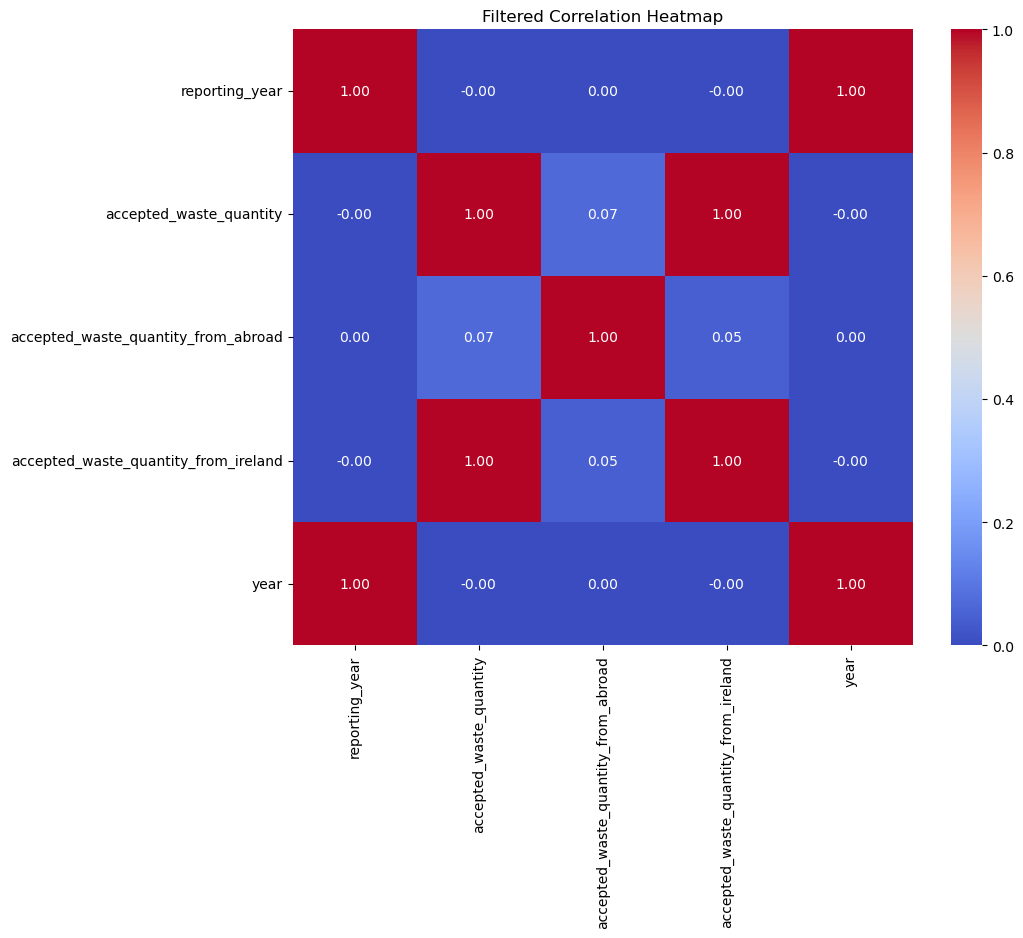

In [83]:
# remover colunas com muitos valores ausentes
numeric_df = numeric_df.dropna(axis=1, thresh=int(0.7 * len(numeric_df)))

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Filtered Correlation Heatmap")
plt.show()